<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/p_1_cluade_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble         import RandomForestClassifier, StackingClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       confusion_matrix, roc_auc_score,
                                       mean_absolute_error,
                                       classification_report)
from imblearn.combine         import SMOTEENN
from imblearn.over_sampling   import SMOTE, ADASYN
from imblearn.combine         import SMOTETomek
from imblearn.under_sampling  import TomekLinks

try:
    from lightgbm import LGBMClassifier
    _HAS_LGB = True
except ImportError:
    _HAS_LGB = False
    print("LightGBM not installed → pip install lightgbm")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [18]:
# ⚠️ CHANGE THIS PATH to your CSV file location
DATA_PATH = '/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")

Loaded: 1523 rows × 19 cols


In [19]:
# ── 2. Label Encoding (paper Section 3.2.1) ───────────────────────────────────
# Gender: Male=1, Female=0
# Result: positive=1, negative=0
le_gender = LabelEncoder()
le_result  = LabelEncoder()

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0, 'male': 1, 'female': 0})
df['Result']  = df['Result'].map({'positive': 1, 'negative': 0,
                                   'Positive': 1, 'Negative': 0})

# Handle any remaining string values
if df['Gender'].dtype == object:
    df['Gender'] = le_gender.fit_transform(df['Gender'])
if df['Result'].dtype == object:
    df['Result'] = le_result.fit_transform(df['Result'])

print(f"Class distribution:\n{df['Result'].value_counts()}")

Class distribution:
Result
1    1042
0     481
Name: count, dtype: int64


In [20]:

# ── 3. Feature / Target Split ─────────────────────────────────────────────────
TARGET = 'Result'
X_raw = df.drop(columns=[TARGET])
y_raw = df[TARGET]

print(f"\nFeatures: {X_raw.shape[1]}  |  Target: {TARGET}")


Features: 18  |  Target: Result


In [21]:
# ── 4. Outlier Removal (paper Section 3.2.2) ─────────────────────────────────
# Paper removed outliers using IQR — went from 1523 → 1372 records
# Key columns with outliers: Neutrophils, Lymphocytes, Monocytes,
#                             Eosinophils, RBC, PCT(%)
def remove_outliers_iqr(X, y, cols=None, factor=1.5):
    """Remove rows where any specified column has an IQR outlier."""
    df_temp = X.copy()
    df_temp['__target__'] = y.values
    mask = pd.Series([True] * len(df_temp), index=df_temp.index)

    if cols is None:
        cols = X.select_dtypes(include=[np.number]).columns.tolist()

    for col in cols:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        mask = mask & df_temp[col].between(lower, upper)

    df_clean = df_temp[mask]
    return df_clean.drop(columns=['__target__']), df_clean['__target__']

# Columns known to have outliers per the paper
outlier_cols = ['Neutrophils(%)', 'Lymphocytes(%)', 'Monocytes(%)',
                'Eosinophils(%)', 'RBC', 'PCT(%)']
# Only use columns that actually exist
outlier_cols = [c for c in outlier_cols if c in X_raw.columns]

X_clean, y_clean = remove_outliers_iqr(X_raw, y_raw, cols=outlier_cols, factor=1.5)
print(f"\nAfter outlier removal: {len(X_clean)} rows  "
      f"(removed {len(X_raw) - len(X_clean)})")


After outlier removal: 1338 rows  (removed 185)


In [22]:
# ── 5. Train/Test Split 80/20 (paper Section 3) ──────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clean
)

In [23]:
# ── 6. Feature Scaling (paper Section 3.2.3) ─────────────────────────────────
# StandardScaler: z = (x - μ) / σ  →  mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test_raw)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test_raw.columns)

In [24]:
# ── 7. SMOTEENN Balancing (paper Section 3.2.4) ───────────────────────────────
# Paper tried 5 techniques; SMOTEENN gave best results
print(f"\nBefore SMOTEENN: {y_train.value_counts().to_dict()}")

smoteenn = SMOTEENN(random_state=RANDOM_STATE)
X_res, y_res = smoteenn.fit_resample(X_train_scaled, y_train)

print(f"After  SMOTEENN: {pd.Series(y_res).value_counts().to_dict()}")


Before SMOTEENN: {1: 763, 0: 307}
After  SMOTEENN: {0: 587, 1: 243}


In [25]:
# ── 8. Define Base Learners (paper Table 4) ───────────────────────────────────
# ⚠️  These exact hyperparameters are from the paper
base_learners = [
    ('rf',   RandomForestClassifier(
                 n_estimators=300, max_depth=30,
                 min_samples_split=5, random_state=RANDOM_STATE,
                 n_jobs=-1)),
    ('dt',   DecisionTreeClassifier(
                 criterion='entropy', splitter='random',
                 min_samples_split=5, random_state=RANDOM_STATE)),
    ('svm',  SVC(kernel='rbf', C=1, gamma=0.1,
                 probability=True, random_state=RANDOM_STATE)),
    ('knn',  KNeighborsClassifier(n_neighbors=3, leaf_size=4, p=1)),
]

if _HAS_LGB:
    base_learners.append(
        ('lgbm', LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))
    )
else:
    print("⚠️  LightGBM not available — using GradientBoosting as substitute")
    from sklearn.ensemble import GradientBoostingClassifier
    base_learners.append(
        ('lgbm', GradientBoostingClassifier(random_state=RANDOM_STATE))
    )

# Meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

In [26]:
# ── 9. DengueStackX-19 (paper Section 3.3.7) ─────────────────────────────────
# Stacking with predict_proba, 5-fold CV for meta-feature generation
DengueStackX19 = StackingClassifier(
    estimators      = base_learners,
    final_estimator = meta_learner,
    stack_method    = 'predict_proba',   # probability-based stacking
    cv              = 5,                  # 5-fold for meta-feature gen
    n_jobs          = -1,
    verbose         = 1
)

print("\n── Training DengueStackX-19 ──")
DengueStackX19.fit(X_res, y_res)
print("Training complete!")


── Training DengueStackX-19 ──
Training complete!


In [27]:
# ── 10. Evaluate on Hold-out Test Set ────────────────────────────────────────
y_pred = DengueStackX19.predict(X_test_scaled)
y_prob = DengueStackX19.predict_proba(X_test_scaled)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
mae  = mean_absolute_error(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("\n" + "="*55)
print("       DengueStackX-19  —  Test Set Results")
print("="*55)
print(f"  Accuracy  : {acc*100:.2f}%  (paper: 96.38%)")
print(f"  Precision : {prec*100:.2f}%  (paper: 94.20%)")
print(f"  Recall    : {rec*100:.2f}%  (paper: 94.20%)")
print(f"  F1-Score  : {f1*100:.2f}%  (paper: 94.20%)")
print(f"  MAE       : {mae*100:.2f}%  (paper:  3.62%)")
print(f"  ROC-AUC   : {auc:.4f}   (paper:  0.994)")
print("="*55)


       DengueStackX-19  —  Test Set Results
  Accuracy  : 63.43%  (paper: 96.38%)
  Precision : 78.18%  (paper: 94.20%)
  Recall    : 67.54%  (paper: 94.20%)
  F1-Score  : 72.47%  (paper: 94.20%)
  MAE       : 36.57%  (paper:  3.62%)
  ROC-AUC   : 0.6583   (paper:  0.994)


In [28]:
# ── 11. Compare All Models (baseline vs proposed) ────────────────────────────
print("\n── Comparing all baseline models ──")

all_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'       : DecisionTreeClassifier(criterion='entropy', splitter='random',
                                                    min_samples_split=5, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, max_depth=30,
                                                    min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM'                 : SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=RANDOM_STATE),
    'KNN'                 : KNeighborsClassifier(n_neighbors=3, leaf_size=4, p=1),
    'DengueStackX-19'     : DengueStackX19,   # already fitted
}

if _HAS_LGB:
    all_models['LightGBM'] = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

results = []
for name, model in all_models.items():
    if name != 'DengueStackX-19':
        model.fit(X_res, y_res)
    yp = model.predict(X_test_scaled)
    results.append({
        'Model'     : name,
        'Accuracy'  : f"{accuracy_score(y_test, yp)*100:.2f}%",
        'Precision' : f"{precision_score(y_test, yp, zero_division=0)*100:.2f}%",
        'Recall'    : f"{recall_score(y_test, yp, zero_division=0)*100:.2f}%",
        'F1-Score'  : f"{f1_score(y_test, yp, zero_division=0)*100:.2f}%",
    })

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))


── Comparing all baseline models ──

              Model Accuracy Precision Recall F1-Score
Logistic Regression   41.79%    87.23% 21.47%   34.45%
      Decision Tree   55.22%    80.34% 49.21%   61.04%
      Random Forest   50.75%    75.65% 45.55%   56.86%
                SVM   54.10%    77.87% 49.74%   60.70%
                KNN   47.39%    79.76% 35.08%   48.73%
    DengueStackX-19   63.43%    78.18% 67.54%   72.47%
           LightGBM   57.09%    77.54% 56.02%   65.05%


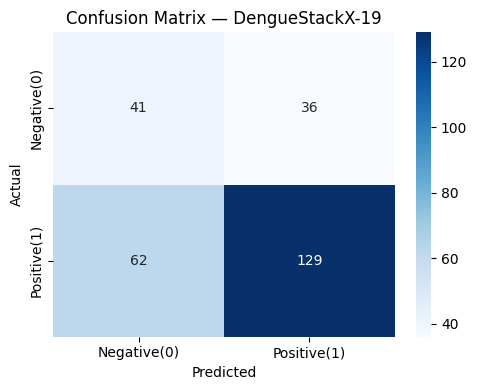

Saved: confusion_matrix_DengueStackX19.png

── 10-Fold Cross-Validation on SMOTEENN-balanced data ──
  10-Fold CV Accuracy  : 95.90% ± 2.96  (paper: 93.65%)
  10-Fold CV Precision : 93.87% ± 5.70  (paper: 90.64%)
  10-Fold CV Recall    : 92.13% ± 7.11  (paper: 88.64%)
  10-Fold CV F1        : 92.86% ± 5.42  (paper: 89.63%)

✅  Done! Check confusion_matrix_DengueStackX19.png


In [29]:
# ── 12. Confusion Matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Negative(0)', 'Positive(1)'],
            yticklabels=['Negative(0)', 'Positive(1)'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — DengueStackX-19')
plt.tight_layout()
plt.savefig('confusion_matrix_DengueStackX19.png', dpi=150)
plt.show()
print("Saved: confusion_matrix_DengueStackX19.png")

# ── 13. 10-Fold Cross-Validation (as in paper Table 5) ───────────────────────
print("\n── 10-Fold Cross-Validation on SMOTEENN-balanced data ──")
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Fresh stack for CV (so it refits properly)
stack_cv = StackingClassifier(
    estimators      = base_learners,
    final_estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    stack_method    = 'predict_proba',
    cv              = 5,
    n_jobs          = -1,
)

cv_results = cross_validate(
    stack_cv, X_res, y_res,
    cv      = skf,
    scoring = ['accuracy', 'precision', 'recall', 'f1'],
    n_jobs  = -1,
    verbose = 0
)

print(f"  10-Fold CV Accuracy  : {cv_results['test_accuracy'].mean()*100:.2f}% ± {cv_results['test_accuracy'].std()*100:.2f}  (paper: 93.65%)")
print(f"  10-Fold CV Precision : {cv_results['test_precision'].mean()*100:.2f}% ± {cv_results['test_precision'].std()*100:.2f}  (paper: 90.64%)")
print(f"  10-Fold CV Recall    : {cv_results['test_recall'].mean()*100:.2f}% ± {cv_results['test_recall'].std()*100:.2f}  (paper: 88.64%)")
print(f"  10-Fold CV F1        : {cv_results['test_f1'].mean()*100:.2f}% ± {cv_results['test_f1'].std()*100:.2f}  (paper: 89.63%)")

print("\n✅  Done! Check confusion_matrix_DengueStackX19.png")